In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("dataset_6.csv", encoding="utf-8-sig", dtype={"region_code": "string"})

df.head(10)

,region_code,region,crop,year,harvested_area_ha,production_t,farms_count
0,R09,Республика Татарстан,лук,2024,1724.7,38406.12,103
1,R05,Кабардино-Балкарская Республика,помидор,2024,869.1,15437.14,24
2,R24,Кировская область,лук,2024,1799.4,49414.01,88
3,R01,Республика Адыгея,горох,2024,9534.4,25874.89,296
4,R12,Алтайский край,лук,2024,1712.8,37412.62,50
5,R05,Кабардино-Балкарская Республика,укроп,2024,408.3,2326.80,12
6,R02,Республика Башкортостан,картофель,2024,4219.8,68048.42,198
7,R23,Кемеровская область - Кузбасс,помидор,2024,806.3,50370.08,26
8,R24,Кировская область,тыква,2024,784.9,10180.50,37
9,R21,Иркутская область,свёкла,2024,1840.0,47702.03,60


In [45]:
my_crop = "баклажан"
sample = df.loc[df["crop"].eq(my_crop)].copy()
sample.head(10)

,region_code,region,crop,year,harvested_area_ha,production_t,farms_count
12,R09,Республика Татарстан,баклажан,2024,497.3,6478.36,14
14,R16,Астраханская область,баклажан,2024,762.7,13984.79,22
21,R20,Воронежская область,баклажан,2024,368.8,6396.24,19
69,R17,Белгородская область,баклажан,2024,NaN,10310.15,16
73,R26,Липецкая область,баклажан,2024,657.0,12975.95,42
77,R07,Республика Марий Эл,баклажан,2024,763.7,14949.24,25
79,R08,Республика Мордовия,баклажан,2024,788.2,21594.10,23
81,R21,Иркутская область,баклажан,2024,770.7,12048.29,36
87,R10,Удмуртская Республика,баклажан,2024,767.6,17035.06,43
92,R25,Курская область,баклажан,2024,404.0,8215.57,18


In [46]:
my_crop = "баклажан"
sample = df.loc[df["crop"].eq(my_crop)].copy()

print("=" * 60)
print("CROP:", my_crop)
print("Raw rows for crop:", len(sample))
print("=" * 60)




print("\n--- MISSING VALUES ---")
print(sample.isna().sum())

print("=" * 60)



print("\n--- FULL DUPLICATES ---")
print(sample[sample.duplicated(keep=False)].to_string())

print("=" * 60)

print("\n--- KEY DUPLICATES (region_code + crop + year) ---")
key = ["region_code", "crop", "year"]
key_dups_rows = sample.duplicated(key)
print(sample[key_dups_rows == True].to_string())

print("=" * 60)

print("\n--- SUSPICIOUS VALUES ---")
for col in ["harvested_area_ha", "production_t", "farms_count"]:
    print(f"\n{col}")
    print("  negative:", (sample[col] < 0).sum())
    print("  zero:", (sample[col] == 0).sum())


print("\n")

# Decision: remove full duplicates (keep first occurrence)
sample = sample.drop_duplicates()
print("\nRows after removing full duplicates:", len(sample))

CROP: баклажан
Raw rows for crop: 31

--- MISSING VALUES ---
region_code          0
region               0
crop                 0
year                 0
harvested_area_ha    1
production_t         0
farms_count          0
dtype: int64

--- FULL DUPLICATES ---
    region_code                 region      crop  year  harvested_area_ha  production_t  farms_count
205         R19  Волгоградская область  баклажан  2024              474.0       8354.49           15
292         R19  Волгоградская область  баклажан  2024              474.0       8354.49           15

--- KEY DUPLICATES (region_code + crop + year) ---
    region_code                 region      crop  year  harvested_area_ha  production_t  farms_count
292         R19  Волгоградская область  баклажан  2024              474.0       8354.49           15

--- SUSPICIOUS VALUES ---

harvested_area_ha
  negative: 0
  zero: 0

production_t
  negative: 0
  zero: 0

farms_count
  negative: 0
  zero: 0



Rows after removing full duplicates

In [47]:
sample["yield_t_per_ha"] = (sample["production_t"] / sample["harvested_area_ha"].where(sample["harvested_area_ha"] > 0))

In [48]:
def describe_and_outliers(series, name):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]

    print(f"\n--- {name} ---")
    print(f"count: {s.count()}")
    print(f"mean: {s.mean():.4f}")
    print(f"median: {s.median():.4f}")
    print(f"min: {s.min():.4f}")
    print(f"max: {s.max():.4f}")
    print(f"std (ddof=1): {s.std(ddof=1):.4f}")
    print(f"Q1: {q1:.4f}")
    print(f"Q3: {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"1.5 IQR lower bound: {lower:.4f}")
    print(f"1.5 IQR upper bound: {upper:.4f}")
    print(f"outlier candidates count: {outliers.count()}")
    if outliers.count() > 0:
        print("outlier candidates:")
        print(outliers)
    return s

prod = describe_and_outliers(sample["production_t"], "Production, t")
yld = describe_and_outliers(sample["yield_t_per_ha"], "Yield, t/ha")


--- Production, t ---
count: 30
mean: 14029.9987
median: 11504.4500
min: 6128.3900
max: 61584.5300
std (ddof=1): 10431.2753
Q1: 8250.3000
Q3: 16137.4875
IQR: 7887.1875
1.5 IQR lower bound: -3580.4813
1.5 IQR upper bound: 27968.2687
outlier candidates count: 1
outlier candidates:
337    61584.53
Name: production_t, dtype: float64

--- Yield, t/ha ---
count: 29
mean: 18.8163
median: 18.3359
min: 12.7878
max: 27.3967
std (ddof=1): 2.9531
Q1: 17.3434
Q3: 20.3356
IQR: 2.9922
1.5 IQR lower bound: 12.8551
1.5 IQR upper bound: 24.8238
outlier candidates count: 2
outlier candidates:
79     27.396727
286    12.787788
Name: yield_t_per_ha, dtype: float64


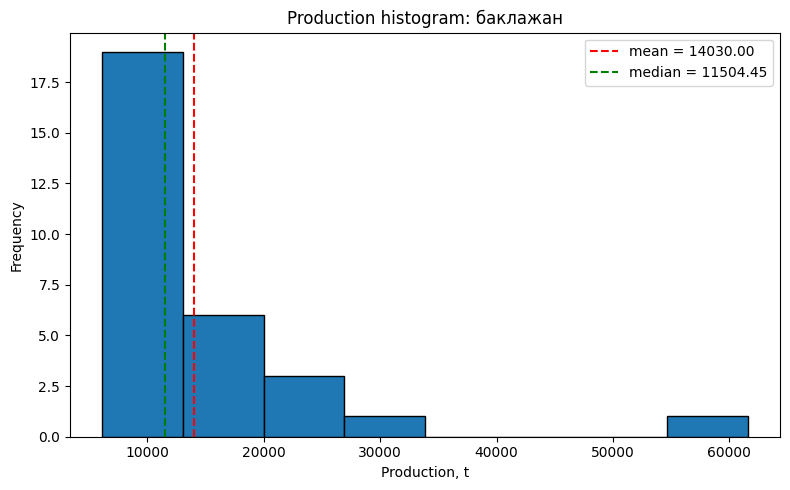

In [49]:
plt.figure(figsize=(8, 5))
plt.hist(prod, bins=8, edgecolor="black")
plt.axvline(prod.mean(), color="red", linestyle="--", label=f"mean = {prod.mean():.2f}")
plt.axvline(prod.median(), color="green", linestyle="--", label=f"median = {prod.median():.2f}")
plt.title("Production histogram: баклажан")
plt.xlabel("Production, t")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

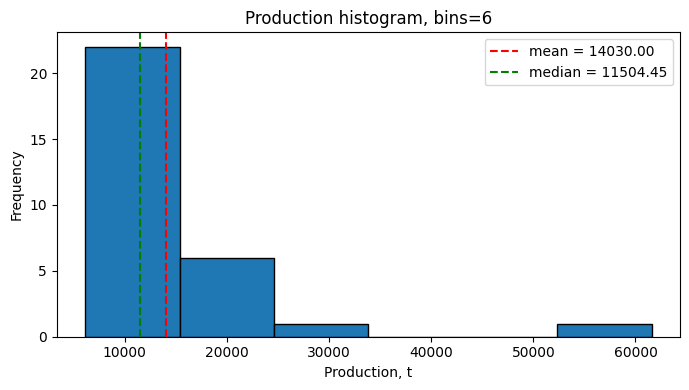

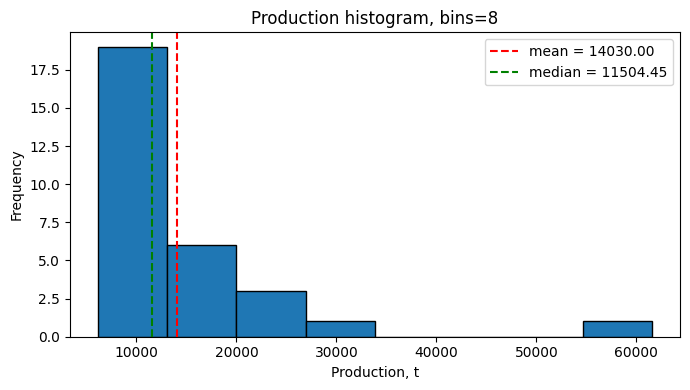

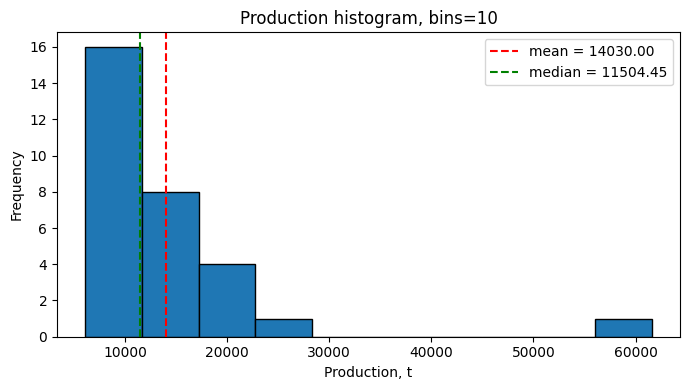

In [50]:
for bins in [6, 8, 10]:
    plt.figure(figsize=(7, 4))
    plt.hist(prod, bins=bins, edgecolor="black")
    plt.axvline(prod.mean(), color="red", linestyle="--", label=f"mean = {prod.mean():.2f}")
    plt.axvline(prod.median(), color="green", linestyle="--", label=f"median = {prod.median():.2f}")
    plt.title(f"Production histogram, bins={bins}")
    plt.xlabel("Production, t")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

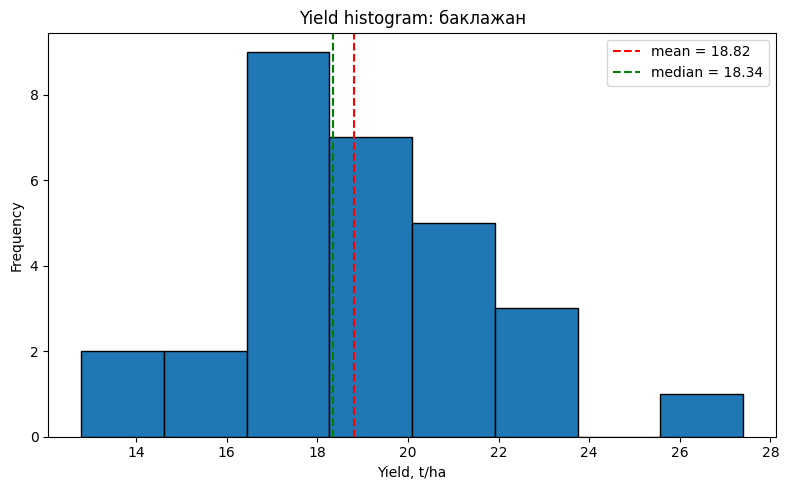

In [51]:
plt.figure(figsize=(8, 5))
plt.hist(yld, bins=8, edgecolor="black")
plt.axvline(yld.mean(), color="red", linestyle="--", label=f"mean = {yld.mean():.2f}")
plt.axvline(yld.median(), color="green", linestyle="--", label=f"median = {yld.median():.2f}")
plt.title("Yield histogram: баклажан")
plt.xlabel("Yield, t/ha")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
top5 = (
    sample.dropna(subset=["production_t"])
    .sort_values("production_t", ascending=False)
    .head(5)
)
print("\n--- TOP-5 REGIONS BY PRODUCTION ---")
print(top5[["region_code", "region", "production_t", "harvested_area_ha", "yield_t_per_ha"]].to_string())


--- TOP-5 REGIONS BY PRODUCTION ---
    region_code                 region  production_t  harvested_area_ha  yield_t_per_ha
337         R14    Ставропольский край      61584.53             3558.8       17.304858
110         R15       Амурская область      27196.62             1406.8       19.332258
79          R08    Республика Мордовия      21594.10              788.2       27.396727
157         R28  Нижегородская область      21050.33             1045.5       20.134223
278         R12         Алтайский край      20837.66             1080.1       19.292343


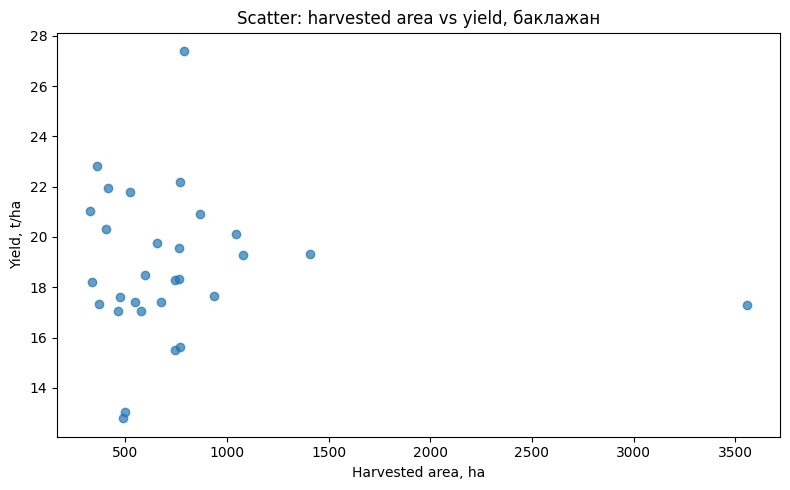

In [53]:
plt.figure(figsize=(8, 5))
plt.scatter(sample["harvested_area_ha"], sample["yield_t_per_ha"], alpha=0.7)
plt.title("Scatter: harvested area vs yield, баклажан")
plt.xlabel("Harvested area, ha")
plt.ylabel("Yield, t/ha")
plt.tight_layout()
plt.show()